# Clustering of RNA Structures

This notebook provides a starting point for the different tasks involved in clustering RNA secondary structures.

## Tasks covered
1. **Data loading** – load RNA sequences and secondary structures
2. **Feature extraction** – convert dot-bracket notation into numerical feature vectors
3. **Pairwise distance computation** – compare structures using edit distance and base-pair distance
4. **Clustering** – apply K-means and hierarchical (agglomerative) clustering
5. **Evaluation** – measure cluster quality with silhouette score and dendrogram
6. **Visualisation** – PCA projection and heatmap of the distance matrix

## 1. Imports and setup

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import RNA
import time

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

%matplotlib inline
sns.set_theme(style="whitegrid")

## 2. Data loading

RNA secondary structures are commonly stored in **dot-bracket** notation alongside the nucleotide sequence.
Replace the sample data below with your own dataset (e.g. from a FASTA/Stockholm file or a database query).

In [6]:
# Sample dataset: (name, sequence, dot-bracket structure)
records = [
    ("RNA_01", "GCGAUAGC",  "(((....)))"),
    ("RNA_02", "GCGAUAGC",  "((.....))"),
    ("RNA_03", "AUCGCUAGC", "((((...))))"),
    ("RNA_04", "GCAUCGAU",  "...((...))"),
    ("RNA_05", "AUGGCUAG",  "((.......))"),
    ("RNA_06", "CGAUGCAU",  ".((....))."),
    ("RNA_07", "GCUAGCAU",  "((((....))))"),
    ("RNA_08", "AUGCGCUA",  "........"),
    ("RNA_09", "GCAUGCAU",  "(.(...).)."),
    ("RNA_10", "CGAUCGUA",  "(((....)))"),
]

df = pd.DataFrame(records, columns=["name", "sequence", "structure"])
print(f"Loaded {len(df)} structures")
df.head()

Loaded 10 structures


,name,sequence,structure
0,RNA_01,GCGAUAGC,(((....)))
1,RNA_02,GCGAUAGC,((.....))
2,RNA_03,AUCGCUAGC,((((...))))
3,RNA_04,GCAUCGAU,...((...))
4,RNA_05,AUGGCUAG,((.......))


### 2a. Self coded Partitioning

In [7]:
def calculate_partition_function(unpaired_probs, paired_probs, beta, m=3):
    """
    Computes the partition function Z[i,j] for an RNA alignment.
    Based on the recursion: Z[i,j] = Z[i,j-1]*exp(beta*UNP(j)) + sum(...)
    """
    n = len(unpaired_probs)
    # Z matrix including an extra index for Z[i, i-1] = 1.0 cases
    Z = np.zeros((n + 1, n + 1), dtype=np.float64)
    
    # Initialization
    for i in range(n):
        Z[i, i] = np.exp(beta * unpaired_probs[i])
        Z[i, i-1] = 1.0
    if n > 0: Z[n, n-1] = 1.0

    # DP Recursion
    for length in range(1, n):
        for i in range(n - length):
            j = i + length
            
            # Case 1: j is unpaired
            # Z[i, j] = Z[i, j-1] * exp(beta * UNP(j))
            z_val = Z[i, j-1] * np.exp(beta * unpaired_probs[j])
            
            # Case 2: j is paired with some k
            # sum over k: Z[i, k-1] * exp(beta * PAIR(k,j)) * Z[k+1, j-1]
            for k in range(i, j - m):
                # Handle the k=i case where Z[i, k-1] is Z[i, i-1] = 1.0
                term_left = Z[i, k-1] if k > i else 1.0
                z_val += term_left * np.exp(beta * paired_probs[k, j]) * Z[k+1, j-1]
                
            Z[i, j] = z_val
            
    return Z

def stochastic_traceback(i, j, Z, unpaired_probs, paired_probs, beta, structure, m=3):
    """
    Produces a random substructure for indices i..j based on partition function Z.
    """
    if j < i:
        return

    # Select a random float for selecting the case
    x = np.random.uniform(0, Z[i, j])
    
    # Check Case: j is unpaired [cite: 306]
    z_unpaired = (Z[i, j-1] if j > i else 1.0) * np.exp(beta * unpaired_probs[j])
    
    if x < z_unpaired:
        stochastic_traceback(i, j-1, Z, unpaired_probs, paired_probs, beta, structure, m)
        return

    # Check Case: j is paired with k [cite: 309]
    cumulative_z = z_unpaired
    for k in range(i, j - m):
        term_left = Z[i, k-1] if k > i else 1.0
        z_paired = term_left * np.exp(beta * paired_probs[k, j]) * Z[k+1, j-1]
        cumulative_z += z_paired
        
        if x < cumulative_z:
            structure[k] = "("
            structure[j] = ")"
            # Recursively sample the two independent sub-problems
            stochastic_traceback(i, k-1, Z, unpaired_probs, paired_probs, beta, structure, m)
            stochastic_traceback(k+1, j-1, Z, unpaired_probs, paired_probs, beta, structure, m)
            return

def sample_structures(unpaired_probs, paired_probs, beta, num_samples=1000, m=3):
    """Generates a list of sampled RnaMolecule structures."""
    n = len(unpaired_probs)
    Z = calculate_partition_function(unpaired_probs, paired_probs, beta, m)
    
    samples = []
    for _ in range(num_samples):
        struct_list = ["."] * n
        stochastic_traceback(0, n - 1, Z, unpaired_probs, paired_probs, beta, struct_list, m)
        samples.append("".join(struct_list))
    return samples

In [8]:
def db2pairs(dbstring):
    base_pairs = []
    stack = []
    
    for index, char in enumerate(dbstring):
        position = index + 1  
        
        if char == '(':
            stack.append(position)
        elif char == ')':
            if not stack:
                raise ValueError(f"Error at position {position} : No matching opening parenthesis")
            opening_pos = stack.pop()
            base_pairs.append((opening_pos, position))
        elif char == '.':
            continue
        else:
            raise ValueError(f"Incompatible character '{char}' detected at the {position}.")
            
    if stack:
        raise ValueError(f"Error : {len(stack)} No closed parenthesis (positions : {stack}).")
        
    return sorted(base_pairs)

def probability_matrix(samples):
    """Estimates base pair probabilities from samples."""
    n = len(samples[0])
    prob_matrix = np.zeros((n, n))
    
    for s in samples:
        pairs = db2pairs(s) 
        for i, j in pairs:
            prob_matrix[i-1, j-1] += 1
            
    prob_matrix /= len(samples)
    return prob_matrix

### 2b. McCaskill algorithm using the ViennaRNA package

In [9]:
sequence = "GAGUAGUGGAACCAGGCUAUGUUUGUGACUCGCAGACCCU"

# 1. Create a 'fold_compound' for the sequence
md = RNA.md()  # create model details
md.uniq_ML = 1 # activate unique multibranch loop decomposition

fc = RNA.fold_compound(sequence, md)

# 2. Run the McCaskill algorithm (Forward pass)
# This calculates the partition function and returns (ensemble_energy)
(propensity, ensemble_energy) = fc.pf()

# 3. Get the base-pairing probability matrix (Backward pass)
# Returns a matrix where bpp[i][j] is the probability of i and j pairing
bpp_matrix = fc.bpp()

print(f"Ensemble Free Energy: {ensemble_energy:.2f} kcal/mol")
print(f"Probability of base 1 pairing with base 20: {bpp_matrix[1][20]:.4f}")
print("Propensity", propensity)
print("bpp", bpp_matrix)

Ensemble Free Energy: -8.64 kcal/mol
Probability of base 1 pairing with base 20: 0.0005
Propensity ..(((((........)))))(((((((...)))))))...
bpp ((0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 8.640343715432157e-06, 0.0, 0.0, 0.0, 0.0, 2.410004185660465e-05, 0.0037146962113015175, 0.0, 0.0, 0.0, 5.9390471641559546e-05, 2.7592582865121724e-05, 0.0, 0.0004881023543541125, 0.0, 6.17662738676067e-05, 3.221866696092066e-05, 9.152886501594468e-06, 0.0, 3.7806500773040876e-08, 0.0, 0.0, 6.096050491630101e-08, 2.2490047656787908e-08, 0.013961111237572429, 0.0, 5.0598860729871335e-05, 0.0, 0.0, 0.0, 3.499967121394818e-05, 0.0013273719742963577, 0.002900185449102968, 2.3317933484071414e-05), (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 8.421836596690229e-05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.023

In [10]:
def boltzmann_sampling(fold_compound):
    """ 
    return a backtracked structure from a fold_compound where the partition function is already computed
    """ 
    return fold_compound.pbacktrack()

print(boltzmann_sampling(fc))

# Generate 1000 samples as a dataframe
samples_Boltzmann = []
for _ in range(1000):
    struct = boltzmann_sampling(fc)
    mfe_struct, mfe_energy = fc.mfe()
    samples_Boltzmann.append((struct, mfe_energy))
df_samples = pd.DataFrame(samples_Boltzmann, columns=["structure", "mfe_energy"])
print(df_samples.head())

..(((((........)))))(((((((...)))))))...
                                  structure  mfe_energy
0  ..(((((........)))))(((((((...)))))))...        -8.4
1  ..(((((........)))))(((((((...)))))))...        -8.4
2  ..(((((........)))))(((((((...)))))))...        -8.4
3  ..(((((........)))))(((((((...)))))))...        -8.4
4  ..(((((........)))))(((((((...)))))))...        -8.4


### Comparison of the two matrices

Match of our results of partitioning between bpp matrix and the self coded partitioning matrix.

In [11]:
print("longueur de la séquence", len(sequence))
print("taille de la matrice de probabilité", len(bpp_matrix), len(bpp_matrix[0]))
matrix = probability_matrix(df_samples["structure"].tolist())
print("taille de la matrice de probabilité perso", matrix.shape)

longueur de la séquence 40
taille de la matrice de probabilité 41 41
taille de la matrice de probabilité perso (40, 40)


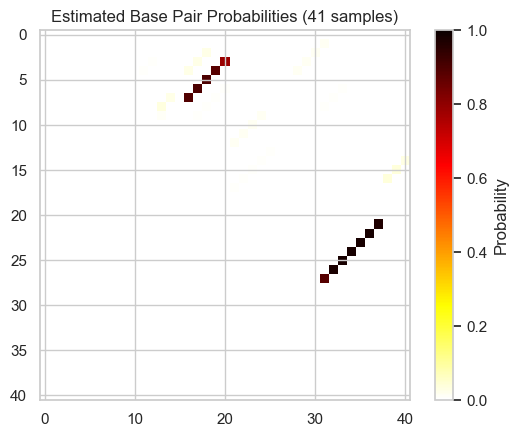

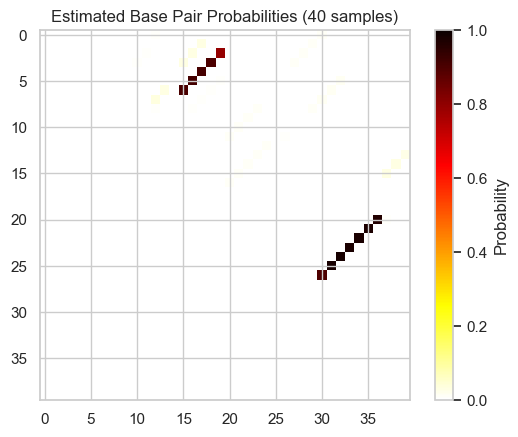

In [12]:
def plot_probability_heatmap(matrix):
    """Visualizes heatmap of base pair probabilities."""
    plt.imshow(matrix, cmap='hot_r', vmin=0, vmax=1)
    plt.title(f"Estimated Base Pair Probabilities ({len(matrix)} samples)")
    plt.colorbar(label="Probability")
    plt.show()

plot_probability_heatmap(bpp_matrix)
plot_probability_heatmap(matrix)

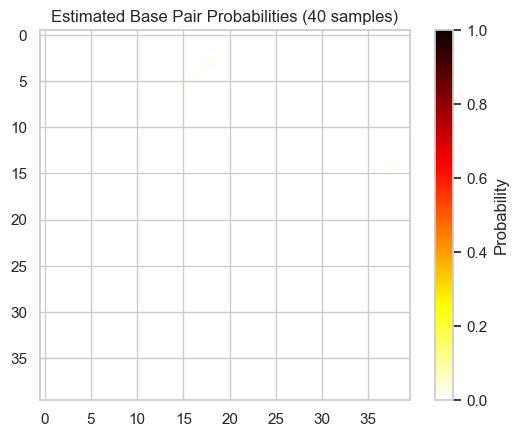

In [13]:
# Mettre la bpp_matric sous forme de matrice de probabilité
bpp_matrix = np.array(bpp_matrix)
#Enlever la première ligne et la première colonne de bpp_matrix pour correspondre à l'indexation 0-based de matrix
reshaped_bpp = bpp_matrix[1:, 1:]
difference_matrix = np.abs(reshaped_bpp-matrix)
plot_probability_heatmap(difference_matrix)

## 3. Feature extraction

We encode each dot-bracket string as a numeric vector:
- `(` → 1
- `)` → -1
- `.` → 0

Sequences of different lengths are zero-padded to the maximum length.

In [14]:
ENCODING = {"(": 1, ")": -1, ".": 0}

def encode_structure(struct: str, max_len: int) -> np.ndarray:
    """Encode a dot-bracket string to a zero-padded numeric array."""
    vec = [ENCODING.get(c, 0) for c in struct]
    vec += [0] * (max_len - len(vec))  # zero-pad
    return np.array(vec, dtype=float)

max_len = df["structure"].str.len().max()
X = np.vstack([encode_structure(s, max_len) for s in df["structure"]])

print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (10, 12)


In [15]:
print("matrice", X)
print("longueur", max_len)

matrice [[ 1.  1.  1.  0.  0.  0.  0. -1. -1. -1.  0.  0.]
 [ 1.  1.  0.  0.  0.  0.  0. -1. -1.  0.  0.  0.]
 [ 1.  1.  1.  1.  0.  0.  0. -1. -1. -1. -1.  0.]
 [ 0.  0.  0.  1.  1.  0.  0.  0. -1. -1.  0.  0.]
 [ 1.  1.  0.  0.  0.  0.  0.  0.  0. -1. -1.  0.]
 [ 0.  1.  1.  0.  0.  0.  0. -1. -1.  0.  0.  0.]
 [ 1.  1.  1.  1.  0.  0.  0.  0. -1. -1. -1. -1.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 1.  0.  1.  0.  0.  0. -1.  0. -1.  0.  0.  0.]
 [ 1.  1.  1.  0.  0.  0.  0. -1. -1. -1.  0.  0.]]
longueur 12


## 4. Pairwise distance computation

Two common distances for RNA structures:
- **Hamming Distance** 
- **Euclidean distance** on the encoded vectors (proxy)
- **Edit distance** (string edit / Levenshtein) on the raw dot-bracket strings

In [16]:
# --- Euclidean distance matrix ---
dist_euclidean = squareform(pdist(X, metric="euclidean"))

# --- String edit distance (Levenshtein) ---
def edit_distance(s1: str, s2: str) -> int:
    """Compute the Levenshtein edit distance between two strings."""
    m, n = len(s1), len(s2)
    dp = list(range(n + 1))
    for i in range(1, m + 1):
        prev = dp[:]
        dp[0] = i
        for j in range(1, n + 1):
            if s1[i - 1] == s2[j - 1]:
                dp[j] = prev[j - 1]
            else:
                dp[j] = 1 + min(prev[j], dp[j - 1], prev[j - 1])
    return dp[n]

structs = df["structure"].tolist()
n = len(structs)
dist_edit = np.zeros((n, n))
for i in range(n):
    for j in range(i + 1, n):
        d = edit_distance(structs[i], structs[j])
        dist_edit[i, j] = d
        dist_edit[j, i] = d

print("Euclidean distance matrix:")
print(np.round(dist_euclidean, 2))
print("\nEdit distance matrix:")
print(dist_edit)

Euclidean distance matrix:
[[0.   1.41 1.41 2.45 2.   1.41 2.   2.45 2.   0.  ]
 [1.41 0.   2.   2.45 2.   1.41 2.45 2.   2.   1.41]
 [1.41 2.   0.   2.45 2.   2.   1.41 2.83 2.45 1.41]
 [2.45 2.45 2.45 0.   2.45 2.45 2.45 2.   2.45 2.45]
 [2.   2.   2.   2.45 0.   2.45 2.   2.   2.45 2.  ]
 [1.41 1.41 2.   2.45 2.45 0.   2.45 2.   2.   1.41]
 [2.   2.45 1.41 2.45 2.   2.45 0.   2.83 2.45 2.  ]
 [2.45 2.   2.83 2.   2.   2.   2.83 0.   2.   2.45]
 [2.   2.   2.45 2.45 2.45 2.   2.45 2.   0.   2.  ]
 [0.   1.41 1.41 2.45 2.   1.41 2.   2.45 2.   0.  ]]

Edit distance matrix:
[[0. 2. 2. 5. 3. 2. 2. 6. 4. 0.]
 [2. 0. 4. 4. 2. 3. 4. 4. 3. 2.]
 [2. 4. 0. 5. 4. 4. 1. 8. 4. 2.]
 [5. 4. 5. 0. 4. 4. 6. 4. 5. 5.]
 [3. 2. 4. 4. 0. 5. 4. 4. 4. 3.]
 [2. 3. 4. 4. 5. 0. 4. 4. 4. 2.]
 [2. 4. 1. 6. 4. 4. 0. 8. 5. 2.]
 [6. 4. 8. 4. 4. 4. 8. 0. 4. 6.]
 [4. 3. 4. 5. 4. 4. 5. 4. 0. 4.]
 [0. 2. 2. 5. 3. 2. 2. 6. 4. 0.]]


In [17]:
def distance_hamming(str1, str2):
    """
    compute the hamming distance between two strings of equal length
    """
    assert(len(str1) == len(str2))
    return sum([str1[i] != str2[i] for i in range(len(str1))])


## 5. Clustering

### 5a. K-means clustering (on encoded feature vectors)

In [18]:
N_CLUSTERS = 3  # adjust based on your data

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init="auto")
labels_kmeans = kmeans.fit_predict(X)

df["cluster_kmeans"] = labels_kmeans
print("K-means cluster assignments:")
print(df[["name", "structure", "cluster_kmeans"]].to_string(index=False))

K-means cluster assignments:
  name    structure  cluster_kmeans
RNA_01   (((....)))               1
RNA_02    ((.....))               1
RNA_03  ((((...))))               2
RNA_04   ...((...))               0
RNA_05  ((.......))               1
RNA_06   .((....)).               1
RNA_07 ((((....))))               2
RNA_08     ........               0
RNA_09   (.(...).).               1
RNA_10   (((....)))               1


### 5b. Hierarchical (agglomerative) clustering (on edit distance matrix)

In [19]:
agg = AgglomerativeClustering(
    n_clusters=N_CLUSTERS,
    metric="precomputed",
    linkage="average",
)
labels_agg = agg.fit_predict(dist_edit)

df["cluster_hierarchical"] = labels_agg
print("Hierarchical cluster assignments:")
print(df[["name", "structure", "cluster_hierarchical"]].to_string(index=False))

Hierarchical cluster assignments:
  name    structure  cluster_hierarchical
RNA_01   (((....)))                     1
RNA_02    ((.....))                     1
RNA_03  ((((...))))                     1
RNA_04   ...((...))                     0
RNA_05  ((.......))                     1
RNA_06   .((....)).                     1
RNA_07 ((((....))))                     1
RNA_08     ........                     0
RNA_09   (.(...).).                     2
RNA_10   (((....)))                     1


### 5c. K-Medoids clustering

In [20]:
import sys

# Create a fake distutils module to satisfy the import
try:
    import distutils.version
except ImportError:
    import packaging.version
    import types
    
    # Create a dummy module
    distutils = types.ModuleType("distutils")
    distutils.version = types.ModuleType("distutils.version")
    distutils.version.LooseVersion = packaging.version.Version
    sys.modules["distutils"] = distutils
    sys.modules["distutils.version"] = distutils.version

from sklearn_extra.cluster import KMedoids  # This should work now

In [21]:
N = 300
samples = N*[None]
for i in range(N):
    samples[i] = fc.pbacktrack()


distance_matrix = np.array([[distance_hamming(samples[i], samples[j]) for i in range(N)] for j in range(N)])
kmedoids = KMedoids(n_clusters=3, metric='precomputed', random_state=42, init='k-medoids++')
clusters = kmedoids.fit(distance_matrix)

labels = kmedoids.labels_
medoid_indices = kmedoids.medoid_indices_

print(f"Cluster Assignments: {labels}")
print(f"Medoid Indices (The 'Centers'): {medoid_indices}")
print(f"Representative RNA for Cluster 0: {samples[medoid_indices[0]]}")

Cluster Assignments: [0 0 0 0 0 0 2 0 1 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 2 2 0 0 0 0 0 0 0 0 0 2
 0 0 2 0 2 0 0 0 1 2 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 2 0
 0 0 0 0 2 2 0 0 0 0 2 1 0 0 0 2 0 0 2 0 0 0 0 0 0 2 0 0 2 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 2 0 0 0 0 0 1 0 0 0 2 0 0 0 0 0 0 0 0 1 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0
 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 2 0 0 0 0 2 0 2 0 2 0 0 0 0
 0 2 0 0 0 0 0 0 0 0 0 2 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 2 2 2]
Medoid Indices (The 'Centers'): [  0 242 187]
Representative RNA for Cluster 0: ..(((((........)))))(((((((...)))))))...


c:\Etudes\X\3A\P2\CSC_52089\Clustering-of-RNA-structures\.venv\Lib\site-packages\sklearn\utils\deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


## 6. Evaluation

### 6a. Silhouette score

In [22]:
sil_kmeans = silhouette_score(X, labels_kmeans)
sil_agg    = silhouette_score(dist_edit, labels_agg, metric="precomputed")

print(f"Silhouette score – K-means (Euclidean features): {sil_kmeans:.3f}")
print(f"Silhouette score – Hierarchical (edit distance): {sil_agg:.3f}")

Silhouette score – K-means (Euclidean features): 0.172
Silhouette score – Hierarchical (edit distance): 0.231


### 6b. Choosing the number of clusters – elbow method

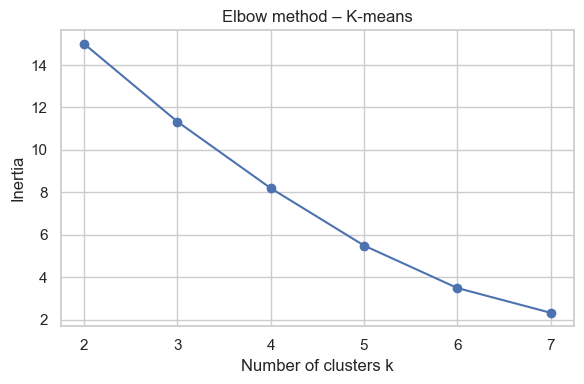

In [23]:
inertias = []
k_range = range(2, min(len(df), 8))
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("Elbow method – K-means")
plt.tight_layout()
plt.show()

## 7. Visualisation

### 7a. PCA projection coloured by K-means cluster

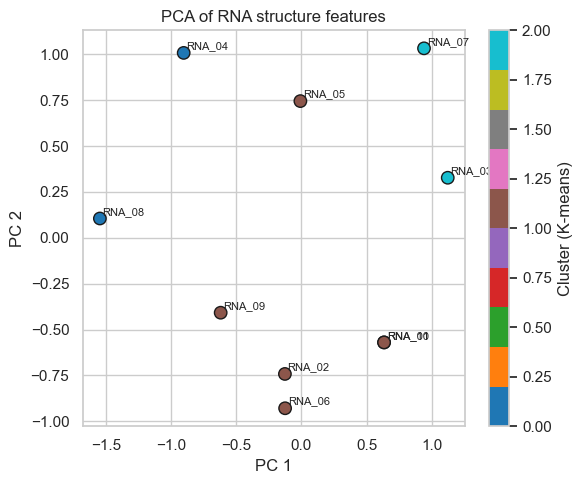

In [24]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=labels_kmeans, cmap="tab10", s=80, edgecolors="k"
)
for i, name in enumerate(df["name"]):
    plt.annotate(name, (X_2d[i, 0] + 0.02, X_2d[i, 1] + 0.02), fontsize=8)
plt.colorbar(scatter, label="Cluster (K-means)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("PCA of RNA structure features")
plt.tight_layout()
plt.show()

### 7b. Heatmap of the edit-distance matrix

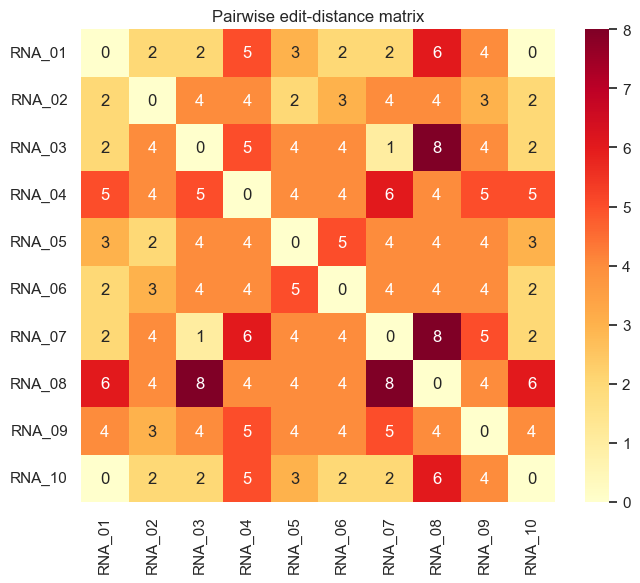

In [25]:
plt.figure(figsize=(7, 6))
sns.heatmap(
    dist_edit,
    xticklabels=df["name"],
    yticklabels=df["name"],
    annot=True, fmt=".0f",
    cmap="YlOrRd"
)
plt.title("Pairwise edit-distance matrix")
plt.tight_layout()
plt.show()

### 7c. Dendrogram (hierarchical clustering)

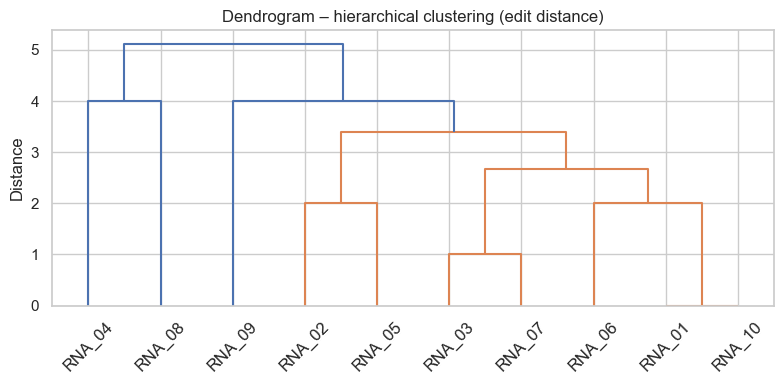

In [26]:
condensed = squareform(dist_edit)
Z = linkage(condensed, method="average")

plt.figure(figsize=(8, 4))
dendrogram(Z, labels=df["name"].tolist(), leaf_rotation=45)
plt.title("Dendrogram – hierarchical clustering (edit distance)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

## 8. Next steps

- Replace the sample data with a real RNA structure dataset (e.g. from [RNAcentral](https://rnacentral.org) or [PDB](https://www.rcsb.org)).
- Implement structure-aware distances such as the **base-pair distance** or **tree edit distance** using tools like `RNAdistance` (ViennaRNA package).
- Explore additional clustering methods (DBSCAN, spectral clustering) suited to non-Euclidean distances.
- Validate clusters against known RNA families or functional annotations.